In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Correct file path and format (CSV instead of Excel)
file_path = "/content/data/AI_SocialMedia_Student_Dataset.csv"

# Load the CSV dataset
df = pd.read_csv(file_path)

# Display the first 5 rows of the dataset
print("--- First 5 Rows of the Dataset ---")
display(df.head())

# Display general info about columns and data types
print("\n--- Dataset Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values per Column ---")
print(df.isnull().sum())

# Statistical summary of numerical features
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 5 Rows of the Dataset ---


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,STU_00001,19,Male,College,5.32,1.21,7.30,1.41,74.06,98.90
1,STU_00002,16,Non-binary,High School,5.21,3.89,7.81,2.48,76.13,89.94
2,STU_00003,25,Male,University,3.61,2.65,6.34,0.06,65.01,76.75
3,STU_00004,23,Male,University,2.93,1.43,6.12,1.37,74.67,87.38
4,STU_00005,20,Non-binary,College,6.52,1.64,5.23,1.14,67.74,88.04



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 16000 non-null  object 
 1   Age                        16000 non-null  int64  
 2   Gender                     16000 non-null  object 
 3   Education_Level            16000 non-null  object 
 4   Daily_Social_Media_Hours   16000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours  16000 non-null  float64
 6   Sleep_Hours                16000 non-null  float64
 7   Physical_Activity_Hours    16000 non-null  float64
 8   Mental_Health_Score        16000 non-null  float64
 9   Physical_Health_Score      16000 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 1.2+ MB

--- Missing Values per Column ---
Student_ID                   0
Age                          0
Gender                       0
Educati

,Age,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
count,16000.00000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,19.03875,4.541791,2.590624,6.545371,1.248359,72.493193,88.020465
std,3.76527,2.403044,1.679376,1.270515,1.038632,9.244818,9.691037
min,13.00000,0.000000,0.000000,2.000000,0.000000,32.560000,48.030000
25%,16.00000,2.840000,1.310000,5.680000,0.310000,66.760000,81.517500
50%,19.00000,4.500000,2.520000,6.540000,1.130000,73.750000,89.455000
75%,22.00000,6.180000,3.750000,7.410000,1.960000,79.550000,97.170000
max,25.00000,14.000000,9.500000,11.150000,5.000000,91.760000,99.980000


In [3]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Check for duplicate rows and drop them if any
print(f"Original number of rows: {df.shape[0]}")
df = df.drop_duplicates()
print(f"Number of rows after removing duplicates: {df.shape[0]}")

# 2. Handling missing values (if any numeric columns have nulls, fill with median; for categorical, fill with mode)
for col in df.select_dtypes(include=["float64", "int64"]).columns:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include=["object"]).columns:
  if df[col].isnull().sum() > 0:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after cleaning:", df.isnull().sum().sum())

# 3. Encoding categorical variables
# Identifying categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("\nCategorical columns found:", list(categorical_cols))

# Apply Label Encoding or One-Hot Encoding
# Here we use LabelEncoder for simplicity, or you can use pd.get_dummies()
label_encoder = LabelEncoder()
for col in categorical_cols:
  df[col] = label_encoder.fit_transform(df[col])

print("\n--- Data Preprocessing Completed Successfully! ---")
display(df.head())

Original number of rows: 16000
Number of rows after removing duplicates: 16000
Missing values after cleaning: 0

Categorical columns found: ['Student_ID', 'Gender', 'Education_Level']

--- Data Preprocessing Completed Successfully! ---


,Student_ID,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Mental_Health_Score,Physical_Health_Score
0,0,19,1,0,5.32,1.21,7.30,1.41,74.06,98.90
1,1,16,2,1,5.21,3.89,7.81,2.48,76.13,89.94
2,2,25,1,2,3.61,2.65,6.34,0.06,65.01,76.75
3,3,23,1,2,2.93,1.43,6.12,1.37,74.67,87.38
4,4,20,2,0,6.52,1.64,5.23,1.14,67.74,88.04


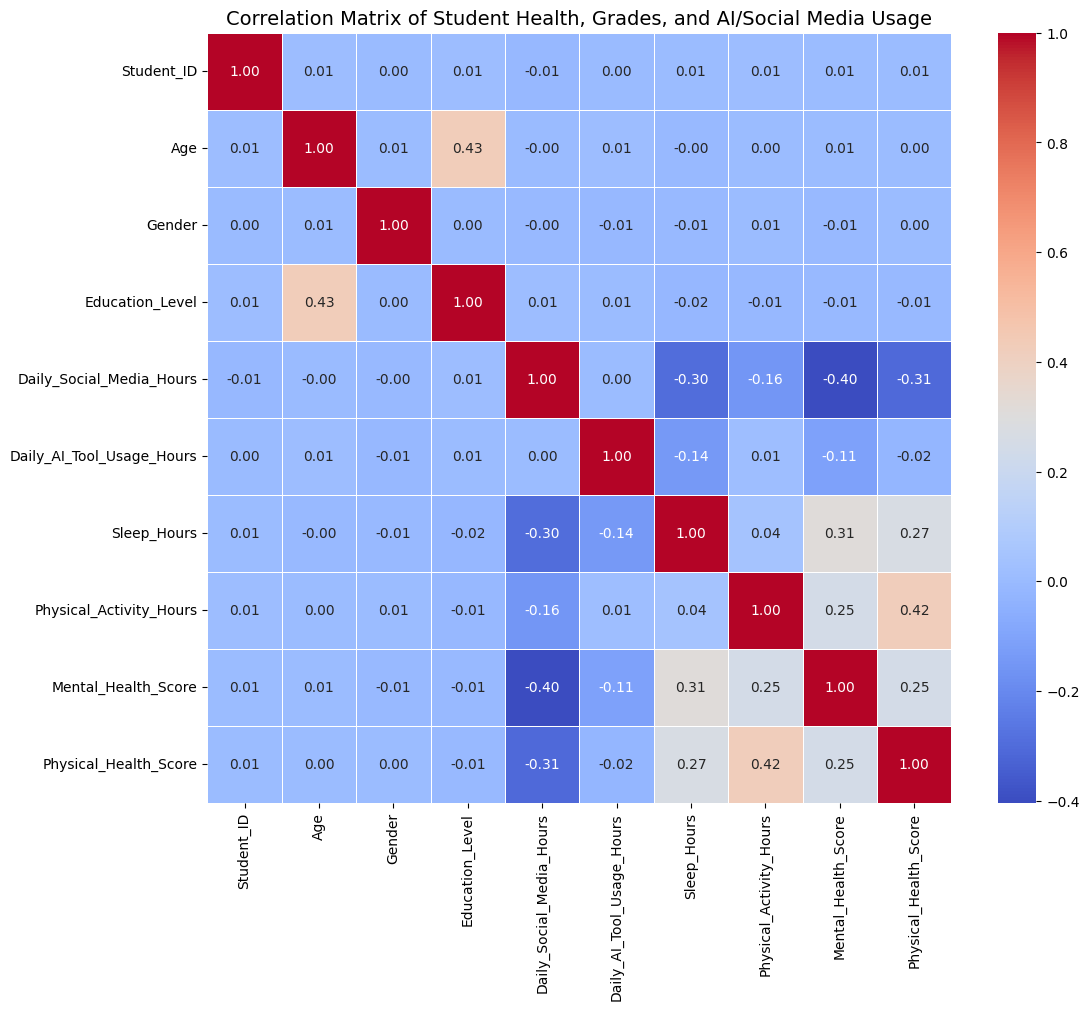

In [4]:
# Set figure size for the heatmap
plt.figure(figsize=(12, 10))

# Calculate correlation matrix
correlation_matrix = df.corr()

# Draw the heatmap using Seaborn
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)

plt.title(
    "Correlation Matrix of Student Health, Grades, and AI/Social Media Usage",
    fontsize=14,
)
plt.show()

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# 1. Create a binary Target column based on Mental_Health_Score
# (e.g., if Mental_Health_Score is below median, label as 1 'At Risk', else 0 'Normal')
median_score = df["Mental_Health_Score"].median()
df["Mental_Health_Risk"] = (df["Mental_Health_Score"] < median_score).astype(int)

# 2. Define Features (X) and Target (y)
# Drop original score columns and ID to avoid data leakage
X = df.drop(
    columns=[
        "Student_ID",
        "Mental_Health_Score",
        "Physical_Health_Score",
        "Mental_Health_Risk",
    ]
)
y = df["Mental_Health_Risk"]

# 3. Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Define 6 different Machine Learning models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# 5. Train and evaluate each model
model_performance = {}

for name, model in models.items():
  print(f"\n--- Training {name} ---")
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)
  model_performance[name] = acc
  print(f"{name} Accuracy: {acc * 100:.2f}%")
  print(classification_report(y_test, y_pred))

# 6. Summary of Model Accuracies
print("\n=== Model Performance Summary ===")
for name, acc in sorted(
    model_performance.items(), key=lambda x: x[1], reverse=True
):
  print(f"{name}: {acc * 100:.2f}%")


--- Training Logistic Regression ---
Logistic Regression Accuracy: 66.25%
              precision    recall  f1-score   support

           0       0.68      0.66      0.67      1658
           1       0.65      0.66      0.65      1542

    accuracy                           0.66      3200
   macro avg       0.66      0.66      0.66      3200
weighted avg       0.66      0.66      0.66      3200


--- Training K-Nearest Neighbors ---
K-Nearest Neighbors Accuracy: 61.12%
              precision    recall  f1-score   support

           0       0.62      0.63      0.63      1658
           1       0.60      0.59      0.60      1542

    accuracy                           0.61      3200
   macro avg       0.61      0.61      0.61      3200
weighted avg       0.61      0.61      0.61      3200


--- Training Support Vector Machine ---
Support Vector Machine Accuracy: 65.94%
              precision    recall  f1-score   support

           0       0.68      0.65      0.67      1658
      

/tmp/ipykernel_1247/1108760201.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracies, y=model_names, palette="viridis")


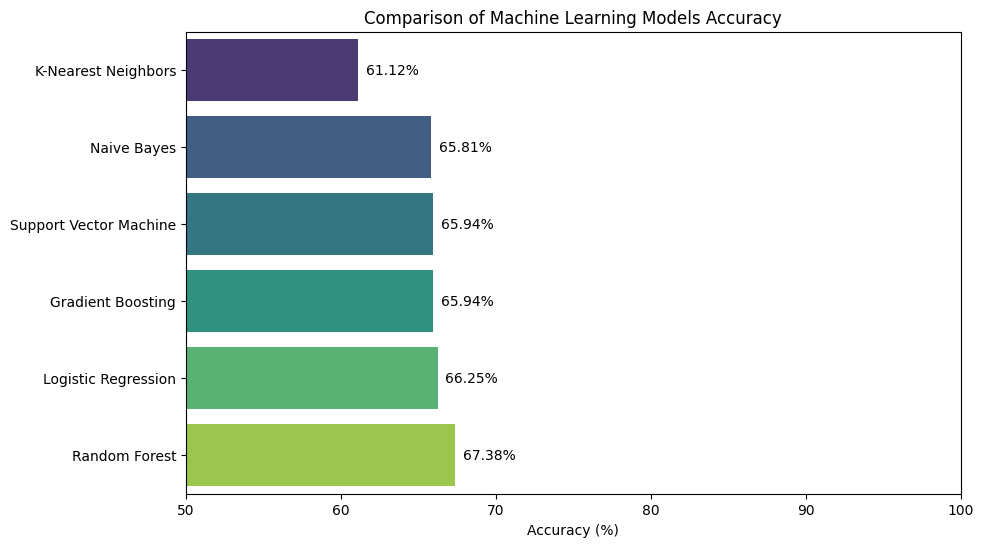

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Plot Model Accuracies Comparison
plt.figure(figsize=(10, 6))
model_names = list(model_performance.keys())
accuracies = [acc * 100 for acc in model_performance.values()]

# Sort values for a better visual bar plot
sorted_indices = np.argsort(accuracies)
model_names = np.array(model_names)[sorted_indices]
accuracies = np.array(accuracies)[sorted_indices]

sns.barplot(x=accuracies, y=model_names, palette="viridis")
plt.xlabel("Accuracy (%)")
plt.title("Comparison of Machine Learning Models Accuracy")
plt.xlim(50, 100)
for index, value in enumerate(accuracies):
  plt.text(value + 0.5, index, f"{value:.2f}%", va="center")
plt.show()



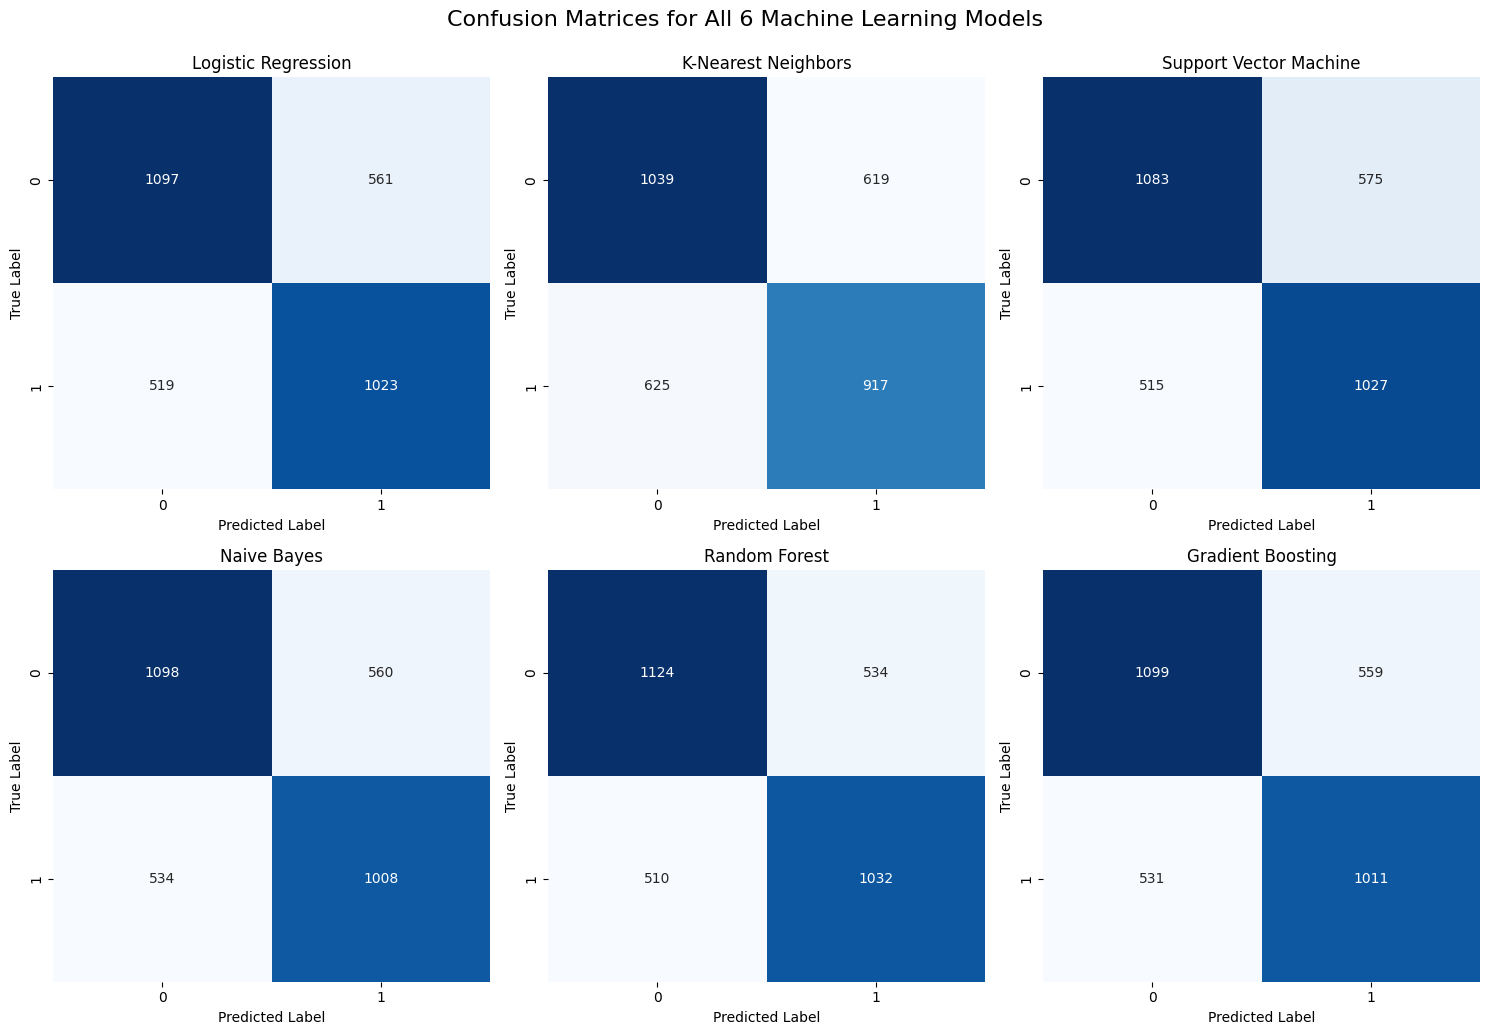

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Set up the subplot grid (2 rows, 3 columns for 6 models)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Loop through each model to calculate confusion matrix and plot
for idx, (name, model) in enumerate(models.items()):
  # Predict on test data using the trained model
  y_pred = model.predict(X_test)

  # Calculate confusion matrix
  cm = confusion_matrix(y_test, y_pred)

  # Plot heatmap for each model
  sns.heatmap(
      cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx]
  )
  axes[idx].set_title(f"{name}", fontsize=12)
  axes[idx].set_xlabel("Predicted Label", fontsize=10)
  axes[idx].set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.suptitle(
    "Confusion Matrices for All 6 Machine Learning Models",
    fontsize=16,
    y=1.03,
)
plt.show()